In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import MultivariateNormal

In [4]:
import numpy as np
import pdb
import math

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [6]:
from models import GMM

In [7]:
class Transform(nn.Module):
    def __init__(self, latent_dim, out_dim, hidden_units=256):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_units),
            nn.ELU(),
            nn.Linear(hidden_units, hidden_units),
            nn.ELU(),
            nn.Linear(hidden_units, hidden_units),
            nn.ELU(),
            nn.Linear(hidden_units, out_dim*2)
        )
        
    def forward(self, x):
        return torch.chunk(self.model(x), 2, dim=-1)
#         return self.model(x)


In [8]:
class Banana(nn.Module):
    name = 'banana'
    def __init__(self, cov):
        super().__init__()
        self.dist = MultivariateNormal(torch.zeros(2), cov)
        self.cov_inv = torch.inverse(cov)
        self.n_dim = cov.size()[0]
        
    def logp(self, x):
        v = torch.stack([x[:, 0], x[:, 1] + 1 + x[:, 0]**2], dim=1)
        return self.dist.log_prob(v)
    
    def score(self, x):
        v = torch.stack([x[:, 0], x[:, 1] + 1 + x[:, 0]**2], dim=1)
        grad = - v @ self.cov_inv.t()
#         grad[:, 0] = grad[:, 0] + 2*x[:, 0] * grad[:, 1]
        
        return torch.stack([grad[:, 0] + 2*x[:, 0] * grad[:, 1], grad[:, 1]], dim=1)
           
    def sample(self, sample_size):
        v = self.dist.sample((sample_size,))
        x1 = v[:, 0]
        x2 = v[:, 1] - x1**2 - 1
        x = torch.stack([x1, x2], dim=1)
        return x

In [9]:
def energy_distance_batch(samples, y):
    """
    samples: (B, d)
    y: (B, d)
    """
    
    B = samples.size(0)
    mask = ~torch.eye(B, dtype=torch.bool)
#     pdb.set_trace()
    # Term 1
    term1 = torch.cdist(samples, y, p=2).mean()

    # Term 2
    term2 = torch.cdist(y, y, p=2).mean()
#     term2 = term2[mask].mean()
    
    # Term 3
    term3 = torch.cdist(samples, samples, p=2).mean()
#     term3 = term3[mask].mean()

    return term1 - 0.5 * term2 - 0.5 * term3

In [10]:
def rbf_kernel(X, Y, h=-1):
    """
    X: [n_particles, dim]
    h: bandwidth (if <0, use median heuristic)
    Returns:
        K: [n_particles, n_particles] kernel matrix
        grad_K: [n_particles, n_particles, dim] derivative w.r.t. first argument
    """
    pairwise_dists = (X.unsqueeze(1) - Y.unsqueeze(0)).pow(2).sum(-1)  # [n,n]
    
    if h <= 0:  # median heuristic
        h = torch.median(pairwise_dists)
        h = h / torch.log(torch.tensor(X.shape[0], dtype=X.dtype) + 1.0)
    
    K = torch.exp(-pairwise_dists / (2 * h))
    return K


def exp_kernel(X, Y, h=-1):
    """
    X: [n_particles, dim]
    h: bandwidth (if <0, use median heuristic)
    Returns:
        K: [n_particles, n_particles] kernel matrix
        grad_K: [n_particles, n_particles, dim] derivative w.r.t. first argument
    """
    pairwise_dists = (X.unsqueeze(1) - Y.unsqueeze(0)).pow(2).sum(-1)  # [n,n]
    
    if h <= 0:  # median heuristic
        h = torch.median(pairwise_dists)
        h = h / torch.log(torch.tensor(X.shape[0], dtype=X.dtype) + 1.0)
    
    K = torch.exp(-pairwise_dists**0.5 / (2 * h))
    return K


def imq_kernel(X, Y, c=1.0, beta=-0.5):
    """
    X: [n_particles, dim]
    Returns:
        K: [n, n] kernel matrix
        grad_K: [n, n, dim] derivative w.r.t. first argument
    """
    pairwise_dists = (X.unsqueeze(1) - Y.unsqueeze(0)).pow(2).sum(-1)  # [n,n]
    K = (c**2 + pairwise_dists) ** beta
    return K

def riesz_kernel(X, Y, alpha=1., epsilon=1e-3):
    """
    X: [n_particles, dim]
    Returns:
        K: [n, n] kernel matrix
        grad_K: [n, n, dim] derivative w.r.t. first argument
    """
    diff = X.unsqueeze(1) - Y.unsqueeze(0)  # [n,n,d]
    dist2 = (diff**2).sum(-1) + epsilon**2  # [n,n]
    
    K = dist2 ** (-alpha/2)
    
    return K

In [11]:
def maximum_mean_discrepancy(samples, y, test=False):
    B = samples.size(0)
    mask = torch.eye(B, dtype=torch.bool)
    
    term1 = torch.cdist(samples, y, p=2)
    term2 = torch.cdist(y, y, p=2)
    
    h = torch.cat([term1, term2], dim=0).median().detach()
    
    term1 = (-term1/(2*h)).exp().mean() 
    
#     term2.masked_fill(mask, 1e6)
    term2 = (-term2/(2*h)).exp().mean()
#     term2_biased = term2.mean()
#     term2 = term2[mask].mean()
    
    
#     term1 = ((h + term1)**(-0.5)).mean()
#     term2 = ((h + term2)**(-0.5)).mean()
       
    
    if test:
        term3 = torch.cdist(samples, samples, p=2)
#         term3.masked_fill(mask, 1e6)
        term3 = (-term3/(2*h)).exp().mean()
#         term3 = ((h + term3)**(-0.5)).mean()
        
        return 0.5*term2 - term1 + 0.5*term3
    else:
        return 0.5*term2 - term1

In [ ]:
class ImVIDrift(nn.Module):
    def __init__(self, target_model, latent_dim=32, hidden_units=256):
        super().__init__()
        self.target = target_model
        self.transform = Transform(latent_dim, target_model.n_dim, hidden_units=hidden_units)
        
        self.latent_dim = latent_dim
        
        torch.set_num_threads(1)
        
    def contour_plot(self, bbox, ax, ngrid=100, samples=None, save_to_path=None):
        xx, yy = np.mgrid[bbox[0]:bbox[1]:100j, bbox[2]:bbox[3]:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        f = np.reshape(self.target.logp(torch.Tensor(positions.T)).numpy(), xx.shape)
        if samples is None:
            samples = self.target.sample(2000).numpy()

        cxx, cyy = np.mgrid[bbox[0]:bbox[1]:30j, bbox[2]:bbox[3]:30j]
        cpositions = np.vstack([cxx.ravel(), cyy.ravel()])
        scores = np.reshape(self.target.score(torch.Tensor(cpositions.T)).detach().numpy(), cpositions.T.shape)

        ax.axis(bbox)
        ax.set_aspect(abs(bbox[1]-bbox[0])/abs(bbox[3]-bbox[2]))
        percentiles = np.linspace(70, 99.99999, 10)  # focus on top 50–99% of density
        levels = np.percentile(f, percentiles)
        cfset = ax.contourf(xx, yy, f, cmap='Blues', alpha=0.8, levels=levels)
        ax.plot(samples[:, 0], samples[:,1], '.', markersize=1, color='#ff7f0e')

        ax.quiver(cxx, cyy, scores[:, 0], scores[:, 1], width=0.002)

        if save_to_path is not None:
            plt.savefig(save_to_path, bbox_inches='tight')
            
            
#     def sample(self, batch_size):
#         samp_z = torch.randn(batch_size, self.latent_dim)
#         samp_x = self.transform(samp_z)
        
#         return samp_x
    
    
    def sample(self, batch_size, log_std_min=-3):
        samp_z = torch.randn(batch_size, self.latent_dim)
        mean, log_std = self.transform(samp_z)
        log_std = log_std.clamp(log_std_min)
        samp_x_raw = torch.randn_like(mean)        
        samp_x = samp_x_raw * log_std.exp() + mean
        
        return samp_x
    
    
    def mala(self, samp_x, stepsz, anneal_coef=1.0):
        random_noise = torch.randn_like(samp_x)
        prop_x = samp_x + stepsz * anneal_coef*self.target.score(samp_x) + math.sqrt(2*stepsz) * random_noise
        
        logq_prop_x = torch.sum(-0.5*math.log(2*math.pi) - 0.5*math.log(2*stepsz) - 0.5*random_noise**2, dim=-1)       
        backward_mean =  prop_x + stepsz * anneal_coef*self.target.score(prop_x)         
        logq_prop_x_backward = torch.sum(-0.5*math.log(2*math.pi) - 0.5*math.log(2*stepsz) - 0.5*(samp_x - backward_mean)**2/(2*stepsz), dim=-1)
                
        curr_logp_x = anneal_coef * self.target.logp(samp_x)
        prop_logp_x = anneal_coef * self.target.logp(prop_x)
        
        log_accept_ratio = prop_logp_x + logq_prop_x_backward - curr_logp_x - logq_prop_x
        
        accept = (torch.log(torch.rand_like(log_accept_ratio)) < log_accept_ratio)
        
        if samp_x.dim() == 1:
            return prop_x if accept else samp_x
        else:
            return torch.where(accept.unsqueeze(-1), prop_x, samp_x), accept.float().mean()
        
    
    def sgld(self, samp_x, stepsz, anneal_coef=1.0):
        prop_x = samp_x + stepsz * anneal_coef * self.target.score(samp_x) + math.sqrt(2*stepsz) * torch.randn_like(samp_x)
        
        return prop_x
               
            
#     def hmc(self, samp_x, stepsz, num_leapfrogs):       
#     def svgd()       
            
        
    def drift_loss(self, stepsz, anneal_coef, batch_size=32, method='sgld'):
        samp_x = self.sample(batch_size)       
#         drift_term = stepsz_star*self.target.score(samp_x) + math.sqrt(2*stepsz) * torch.randn_like(samp_x)
        if method == 'sgld':
            next_x = self.sgld(samp_x, stepsz, anneal_coef)
        elif method == 'mala':
            next_x, accept_rate = self.mala(samp_x, stepsz, anneal_coef)
        else:
            raise NotImplementedError
        
#         return energy_distance_batch(next_x.detach(), samp_x)
        return maximum_mean_discrepancy(next_x.detach(), samp_x)

    
            
#     def sample(self, batch_size, log_std_min=-3):
#         samp_z = torch.randn(batch_size, self.latent_dim)
#         mean, log_std = self.encoder(samp_z)
#         log_std = log_std.clamp(log_std_min)
#         samp_x_raw = torch.randn_like(mean)        
#         samp_x = samp_x_raw * log_std.exp() + mean       
#         return samp_x, samp_x_raw/log_std.exp()
                   
#     def ksd(self, anneal_coef, batch_size=32, kernel_fun=rbf_kernel):
#         samp_x, neg_cond_score = self.sample(batch_size*2)
#         samp_x_1, samp_x_2 = torch.chunk(samp_x, 2, dim=0)          
#         score_diff = anneal_coef*self.target.score(samp_x) + neg_cond_score
#         score_diff_1, score_diff_2 = torch.chunk(score_diff, 2, dim=0)
#         K = kernel_fun(samp_x_1, samp_x_2)
        
#         return torch.mean(K*(score_diff_1@score_diff_2.t()))
    
#     def kdrift(self, anneal_coef, batch_size=32, kernel_fun=rbf_kernel):
#         samp_x, neg_cond_score = self.sample(batch_size)
#         score_diff = anneal_coef*self.target.score(samp_x) + neg_cond_score
#         K = kernel_fun(samp_x, samp_x)
#         f_score_ = K@score_diff
        
#         return -torch.mean(torch.sum(f_score_.detach() * samp_x, dim=-1))
        
    

    def learn(self, stepsz, drift_stepsz=0.1, max_iter=10000, batch_size=32, test_freq=1000,
              anneal_freq=10000, anneal_rate=0.75, warm_up_interval=5000, method='sgld'):        
#         ksd_est = []
#         accept_rates = []
        
        optimizer = torch.optim.Adam(self.parameters(), lr=stepsz) 
#         anneal_coef = 1.0
        for i in range(1, max_iter+1):
            anneal_coef = min(1.0, 0.1 + i*1.0/warm_up_interval)
            loss = self.drift_loss(drift_stepsz/anneal_coef, anneal_coef, batch_size=batch_size, method=method)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
#             ksd_est.append(loss.item())
#             accept_rates.append(accept_rate.item())
            
#             pdb.set_trace()
            
            
            if i % test_freq == 0:
                with torch.no_grad():
                    samp_x = self.sample(2000)
                    target_x = self.target.sample(2000)
                    ksd_est = maximum_mean_discrepancy(target_x, samp_x, test=True)
#                 print('[Iter {:d}/{:d}] [KSD loss: {:.4f}] | MALA accept rate: {:.2f}'.format(i, max_iter, ksd_est, np.mean(accept_rates)))
                print('[Iter {:d}/{:d}] [KSD loss: {:.4f}]'.format(i, max_iter, ksd_est))
#                 ksd_est = []
#                 accept_rates = []
                
                fig, ax = plt.subplots(figsize=(5, 5))
                save_to_path = 'results/' + self.target.name + '/drift/MMD/{:d}.png'.format(i)
                import os
                os.makedirs(os.path.dirname(save_to_path), exist_ok=True)
#                 with torch.no_grad():
#                     samp_x = self.sample(2000)
#                 self.contour_plot([-3, 3, -8, 1], ax, samples=samp_x.numpy(), save_to_path=save_to_path)
#                 self.contour_plot([-5, 5, -5, 5], ax, samples=samp_x.numpy(), save_to_path=save_to_path)
                self.contour_plot([-1.5, 1.5, -1.5, 1.5], ax, samples=samp_x.numpy(), save_to_path=save_to_path)
                plt.close()
                
            if i % anneal_freq == 0:
#                 anneal_coef *= anneal_rate
                for g in optimizer.param_groups:
                    g['lr'] *= anneal_rate

In [13]:
# cov = torch.tensor([[1., 0.9],[0.9, 1.]])
# target_model = Banana(cov)
target_model = GMM(n_clusters=8, sigma=0.1, r=1)

In [14]:
model = ImVIDrift(target_model, hidden_units=256)

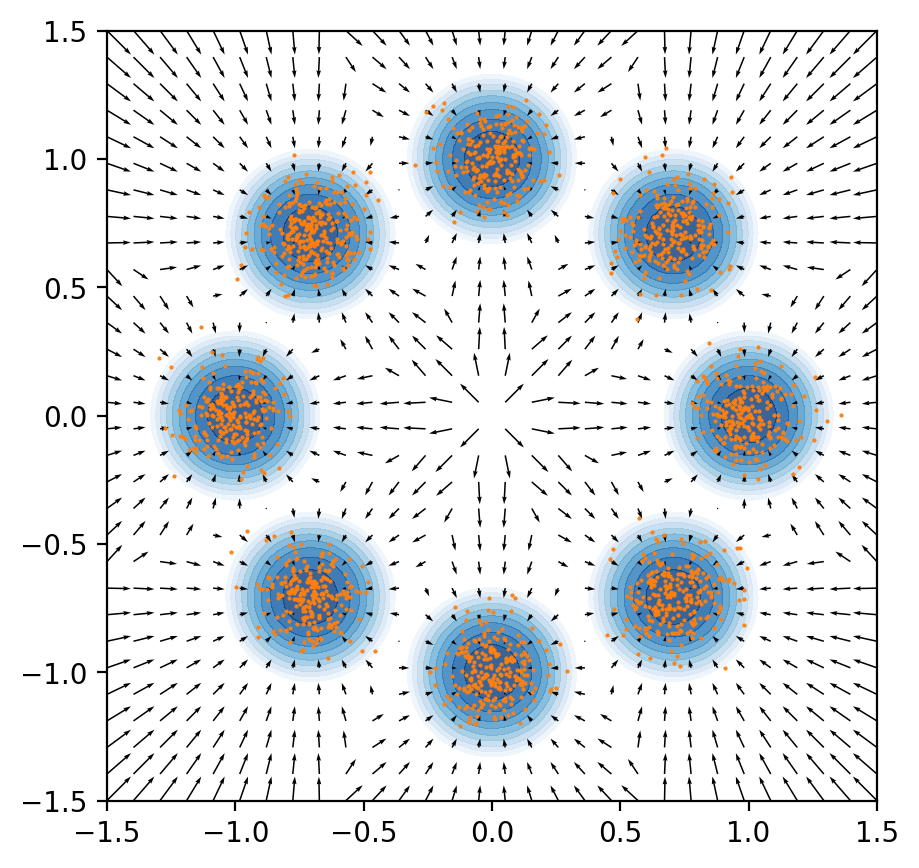

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
# model.contour_plot([-5, 5, -5, 5], ax)
model.contour_plot([-1.5, 1.5, -1.5, 1.5], ax)
# model.contour_plot([-3, 3, -8, 1], ax)
plt.show()

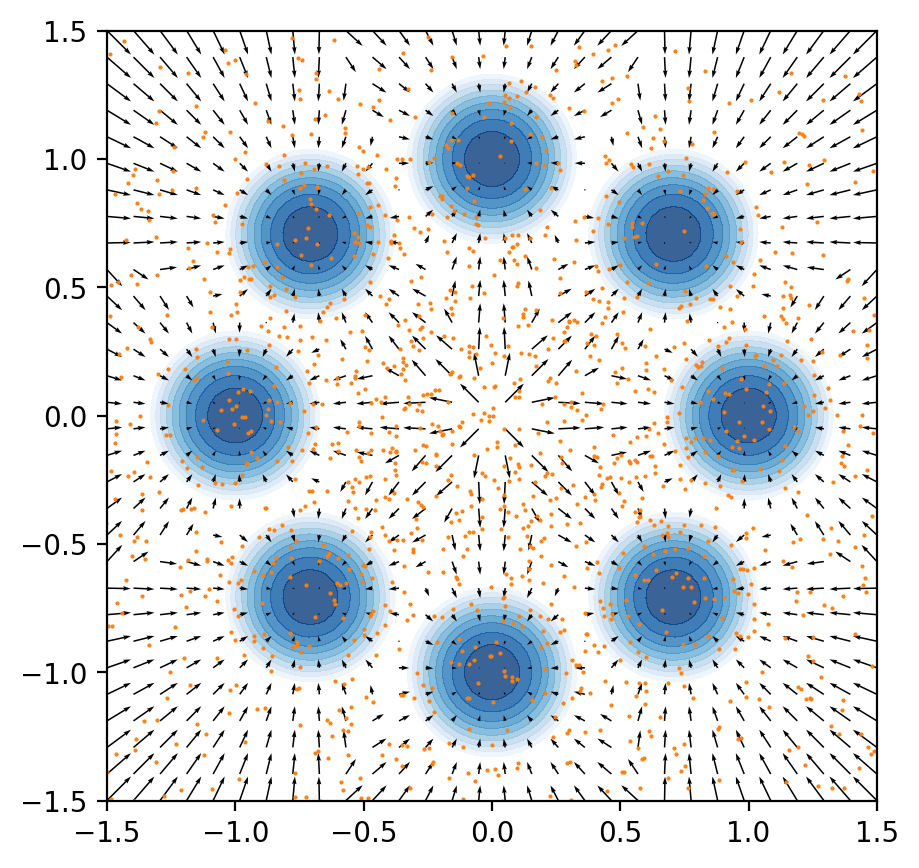

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
samp_x = model.sample(2000)
# model.contour_plot([-5, 5, -5, 5], ax)
model.contour_plot([-1.5, 1.5, -1.5, 1.5], ax, samples=samp_x.detach().numpy())
# model.contour_plot([-3, 3, -8, 1], ax)
plt.show()

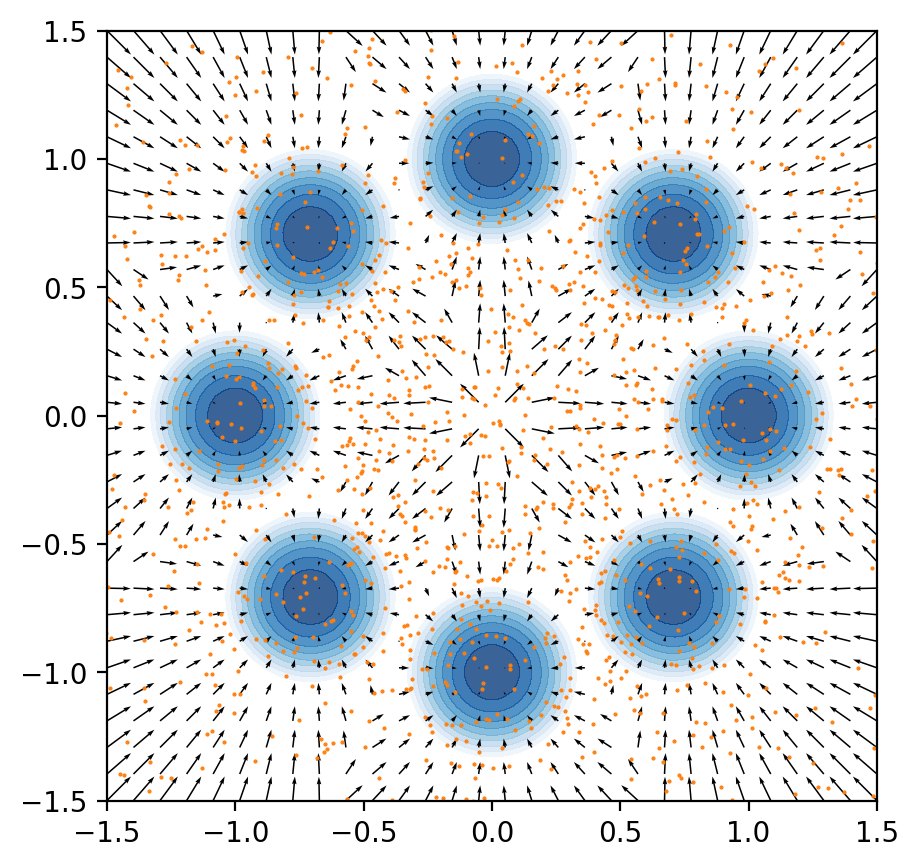

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
samp_x = model.sample(2000)
# model.contour_plot([-5, 5, -5, 5], ax)
model.contour_plot([-1.5, 1.5, -1.5, 1.5], ax, samples=samp_x.detach().numpy())
# model.contour_plot([-3, 3, -8, 1], ax)
plt.show()

[Iter 1000/100000] [KSD loss: 0.0024]


FileNotFoundError: [Errno 2] No such file or directory: 'results/gmm/drift/MMD/1000.png'

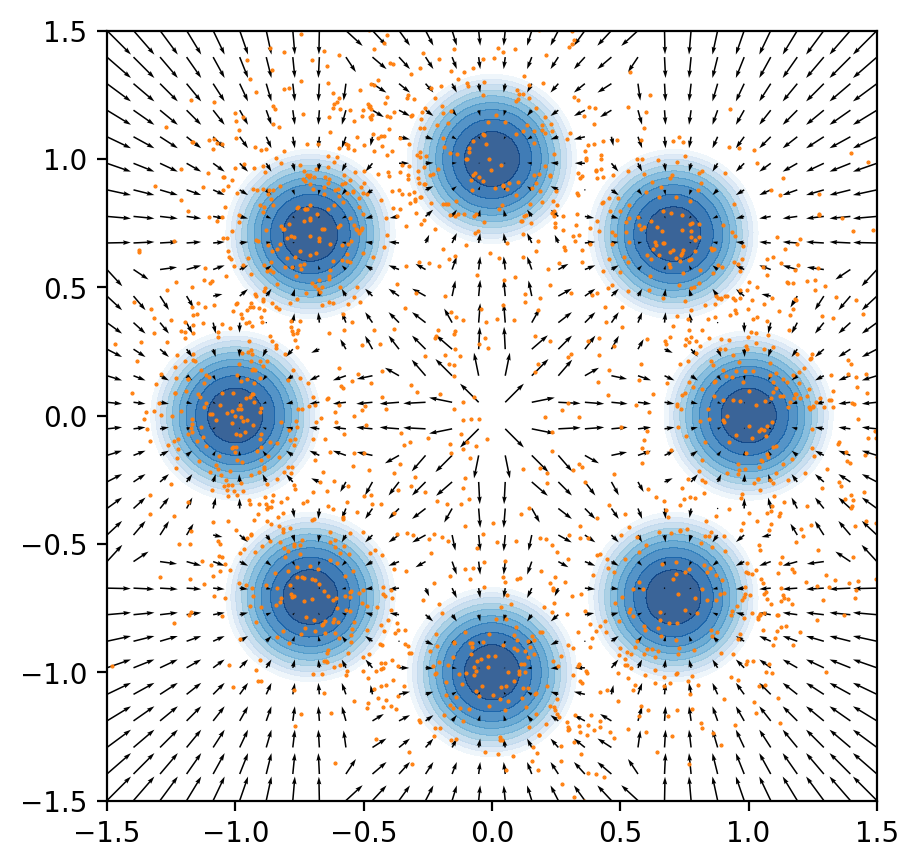

In [19]:
model.learn(0.001, 0.01, 100000, batch_size=128, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='mala')

In [ ]:
model.learn(0.001, 0.01, 100000, batch_size=128, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='mala')

In [ ]:
model.learn(0.001, 0.01, 100000, batch_size=256, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='mala')

In [ ]:
model.learn(0.001, 0.01, 100000, batch_size=256, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='mala')

In [ ]:
model.learn(0.001, 0.005, 100000, batch_size=256, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='sgld')

In [ ]:
model.learn(0.001, 0.005, 100000, batch_size=128, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='mala')

In [ ]:
model.learn(0.001, 0.005, 100000, batch_size=128, warm_up_interval=50000, anneal_freq=5000, anneal_rate=0.75, method='mala')

In [ ]:
model.learn(0.001, 0.005, 100000, batch_size=128, warm_up_interval=100000, anneal_freq=5000, anneal_rate=0.75)